# Métodos Numéricos I — Notebook da Aula 5
## Ajuste por Mínimos Quadrados

**Programa:** PPGMC / UESC  
**Referências-base:** Burden & Faires cap. 8; Antia cap. 4.

Este notebook foi preparado para apoiar a **Aula 5 — Ajuste por Mínimos Quadrados**.

## Objetivos
- compreender o **problema de ajuste de dados**;
- diferenciar **interpolação** de **ajuste**;
- formular o problema de **mínimos quadrados linear**;
- generalizar para **ajuste polinomial**;
- interpretar geometricamente a solução;
- discutir **condicionamento** e sensibilidade numérica.

## 1. Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import pandas as pd
from IPython.display import display

## 2. Motivação: dados reais raramente devem ser interpolados exatamente

Em aplicações reais, os dados:
- contêm ruído;
- possuem erro experimental;
- representam medições imperfeitas.

Nesses casos, em vez de procurar uma curva que passe **exatamente** por todos os pontos, procuramos uma curva que os represente **da melhor forma possível**.

In [2]:
"""
Vamos definir uma função exemplo de tipo polinomial para gerar dados de teste
A função deve gerar pontos acrscidos de um ruiído gaussiano. Deve ser um polinômio de grau 3, 
mas deve ter um comportomanto semelhante ao de um polinômio de gráu 1 no intervalo entre 0 e 3.
A função deve retornar também os coeficientes do polinômio gerado para que possamos comparar com 
os coeficientes encontrados pelo método dos mínimos quadrados.
"""
def gerar_dados_polinomiais_com_ruido(num_pontos=10, grau=3, intervalo=(0, 3), ruido_std=0.5):
    x = np.linspace(intervalo[0], intervalo[1], num_pontos)
    # Gerar um polinômio de grau 3 com coeficientes aleatórios
    coeficientes = np.random.rand(grau + 1) * 2 - 1  # Coeficientes entre -1 e 1
    y = np.polyval(coeficientes, x)  # Avaliar o polinômio nos pontos x
    # Adicionar ruído gaussiano
    ruido = np.random.normal(0, ruido_std, size=y.shape)
    y_ruidoso = y + ruido
    return x, y_ruidoso, coeficientes

In [3]:
#x = np.array([0, 1, 2, 3], dtype=float)
#y = np.array([1.1, 2.0, 2.9, 4.2], dtype=float)
x,y,coeficientes = gerar_dados_polinomiais_com_ruido(num_pontos=4, grau=3, intervalo=(0, 3), ruido_std=0.5)
#Vamos criar um pandas dataframe com estes dados para melhor visualização
df = pd.DataFrame({'x': x, 'y': y})
display(df)

,x,y
0,0.0,-1.019661
1,1.0,-0.305625
2,2.0,2.561391
3,3.0,6.286118


In [4]:

x_plot = np.linspace(0, 3, 1200)
y_pol = np.polyval(coeficientes, x_plot)

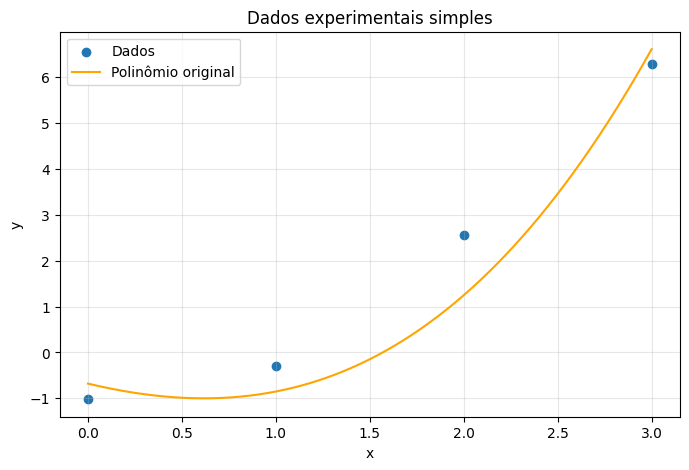

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, y_pol, label="Polinômio original", color='orange')
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados experimentais simples")
plt.legend()
plt.show()

A função 'numpy.polyfit' não é uma função de interpolação; ela faz ajuste polinomial por mínimos quadrados. Isso está de acordo com a documentação oficial do __NumPy__: a função recebe um conjunto de pontos $(x_i,y_i)$ e retorna os coeficientes de um polinômio de grau escolhido pelo usuário que minimiza a soma dos quadrados dos resíduos. Se você escolher grau $n−1$ para $n$ pontos distintos, o ajuste pode coincidir exatamente com todos os pontos, produzindo um polinômio que passa por eles. Nesse caso, o resultado se parece com interpolação.

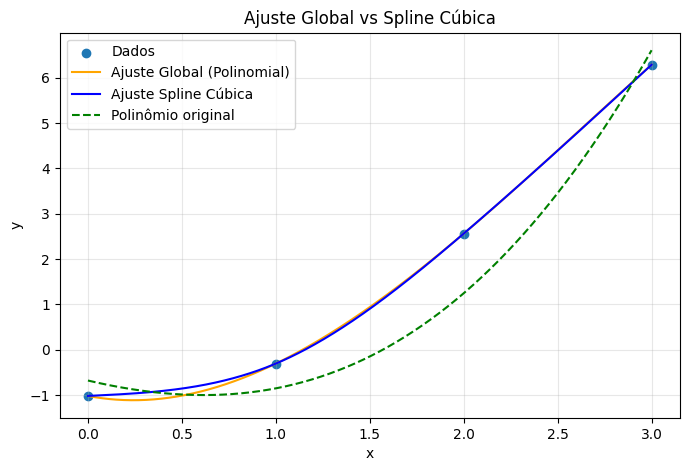

In [6]:
coef_global = np.polyfit(x, y, deg=3)  # Ajuste polinomial de grau 3 ou menor
p_global = np.poly1d(coef_global)
y_global = p_global(x_plot)

cs = CubicSpline(x, y, bc_type='natural')
y_spline = cs(x_plot)

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, y_global, label="Ajuste Global (Polinomial)", color='orange')
plt.plot(x_plot, y_spline, label="Ajuste Spline Cúbica", color='blue')  
plt.plot(x_plot, y_pol, label="Polinômio original", color='green', linestyle='--')
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste Global vs Spline Cúbica")
plt.legend()
plt.show()

## 3. Interpolação × Ajuste

### Interpolação
Procura uma função que satisfaça:
$$
f(x_i)=y_i
$$

### Ajuste
Procura uma função que satisfaça, aproximadamente:
$$
f(x_i) \approx y_i
$$

Essa distinção é central em modelagem numérica.

## 4. Formulação do problema de mínimos quadrados linear

Queremos ajustar uma reta:

$$
f(x)=a+bx
$$

aos dados $(x_i,y_i)$.

Definimos o resíduo em cada ponto:
$
e_i = y_i - (a+bx_i)
$

e minimizamos a soma dos quadrados dos resíduos:
$$
S(a,b)=\sum_{i=1}^n (y_i-a-bx_i)^2
$$

## 5. Exemplo-base: ajuste linear de uma reta

Usaremos o conjunto:

$$
(0,1.1), (1,2.0), (2,2.9), (3,4.2)
$$

Esse exemplo é excelente para os slides da aula.

In [7]:
x = np.array([0, 1, 2, 3], dtype=float)
y = np.array([1.1, 2.0, 2.9, 4.2], dtype=float)

coef = np.polyfit(x, y, 1)
b, a = coef[0], coef[1]

print("Coeficiente angular b =", b)
print("Intercepto a =", a)

Coeficiente angular b = 1.0200000000000005
Intercepto a = 1.0200000000000002


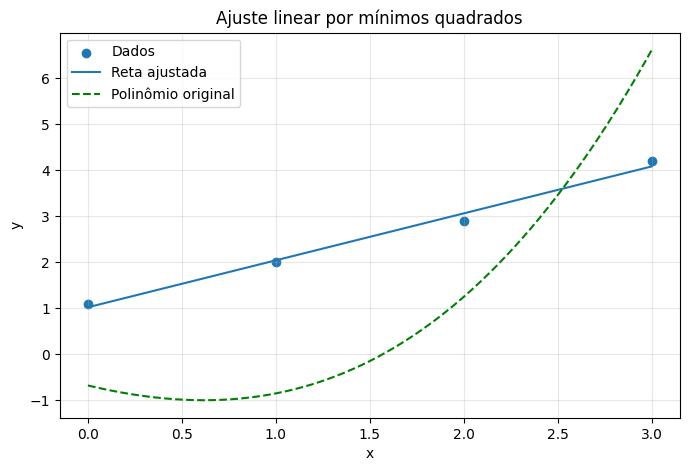

Resíduos: [ 0.08 -0.04 -0.16  0.12]
Soma dos quadrados dos resíduos = 0.048000000000000126


In [9]:
y_fit = a + b*x
residuos = y - y_fit

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Dados")
plt.plot(x, y_fit, label="Reta ajustada")
plt.plot(x_plot, y_pol, label="Polinômio original", color='green', linestyle='--')
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste linear por mínimos quadrados")
plt.legend()
plt.show()

print("Resíduos:", residuos)
print("Soma dos quadrados dos resíduos =", np.sum(residuos**2))

## 6. Sistema normal

O problema linear pode ser escrito como:

$$
A\mathbf{c} \approx \mathbf{y}
$$

onde

$$
A=
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix},
\quad
\mathbf{c}=
\begin{bmatrix}
a \\
b
\end{bmatrix}
$$

A solução de mínimos quadrados satisfaz:

$$
A^T A\mathbf{c}=A^T\mathbf{y}
$$

In [13]:
A = np.column_stack([np.ones_like(x), x])
ATA = A.T @ A
ATy = A.T @ y

c = np.linalg.solve(ATA, ATy)

print("Matriz A:")
print(A)
print("\nMatriz A^T:")
print(A.T)
print("\nMatriz A^T A:")
print(ATA)
print("\nMatriz A^T A c:")
print(ATA @ c)
print("\nA^T y:")
print(ATy)
print("\nSolução pelo sistema normal [a, b]:")
print(c)

Matriz A:
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]

Matriz A^T:
[[1. 1. 1. 1.]
 [0. 1. 2. 3.]]

Matriz A^T A:
[[ 4.  6.]
 [ 6. 14.]]

Matriz A^T A c:
[10.2 20.4]

A^T y:
[10.2 20.4]

Solução pelo sistema normal [a, b]:
[1.02 1.02]


## 7. Interpretação geométrica

O vetor $\mathbf{y}$ geralmente não pertence ao espaço coluna de $A$.

A solução de mínimos quadrados é a **projeção ortogonal** de $\mathbf{y}$ sobre esse subespaço.

Isso implica:

$$
r = y - Ac
$$

é ortogonal às colunas de \(A\), ou seja:

$$
A^T r = 0
$$

In [15]:
c = np.linalg.solve(A.T @ A, A.T @ y)
r = y - A @ c

print("Coeficientes [a, b]:", c)
print("Resíduo r:", r)
print("A^T r:")
print(A.T @ r)

Coeficientes [a, b]: [1.02 1.02]
Resíduo r: [ 0.08 -0.04 -0.16  0.12]
A^T r:
[ 1.33226763e-15 -1.77635684e-15]


## 8. Generalização: ajuste polinomial

Agora procuramos um polinômio de grau \(m\):

$$
p_m(x)=a_0 + a_1x + a_2x^2 + \cdots + a_mx^m
$$

e minimizamos:

$$
\sum_{i=1}^n (y_i-p_m(x_i))^2
$$

Em forma matricial, o sistema continua sendo:

$$
A^T A\mathbf{c}=A^T\mathbf{y}
$$

mas agora $A$ é uma matriz de Vandermonde truncada.

## 9. Exemplo: comparar graus 1, 2 e 3

Vamos observar como o ajuste muda quando aumentamos o grau do polinômio.

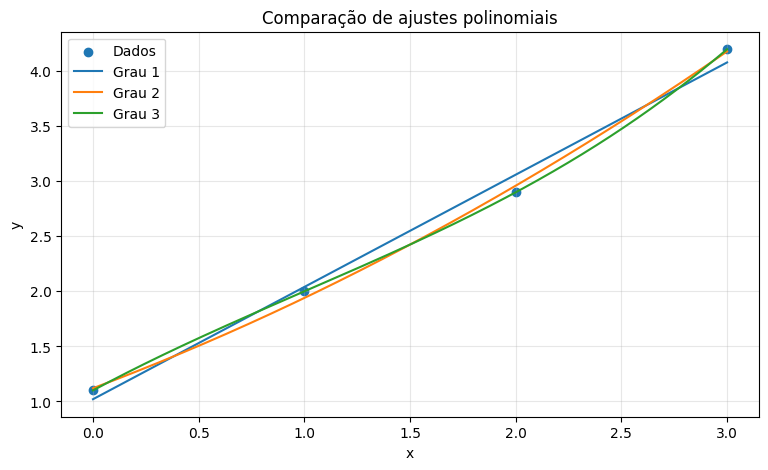

In [16]:
#x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
#y = np.array([1.2, 1.9, 3.0, 3.9, 5.1, 6.2], dtype=float)

#x_plot = np.linspace(x.min(), x.max(), 400)

coef1 = np.polyfit(x, y, 1)
coef2 = np.polyfit(x, y, 2)
coef3 = np.polyfit(x, y, 3)

p1 = np.poly1d(coef1)
p2 = np.poly1d(coef2)
p3 = np.poly1d(coef3)

plt.figure(figsize=(9,5))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, p1(x_plot), label="Grau 1")
plt.plot(x_plot, p2(x_plot), label="Grau 2")
plt.plot(x_plot, p3(x_plot), label="Grau 3")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação de ajustes polinomiais")
plt.legend()
plt.show()

In [17]:
for grau, p in [(1, p1), (2, p2), (3, p3)]:
    residuos = y - p(x)
    sqr = np.sum(residuos**2)
    print(f"Grau {grau}: soma dos quadrados dos resíduos = {sqr:.8f}")

Grau 1: soma dos quadrados dos resíduos = 0.04800000
Grau 2: soma dos quadrados dos resíduos = 0.00800000
Grau 3: soma dos quadrados dos resíduos = 0.00000000


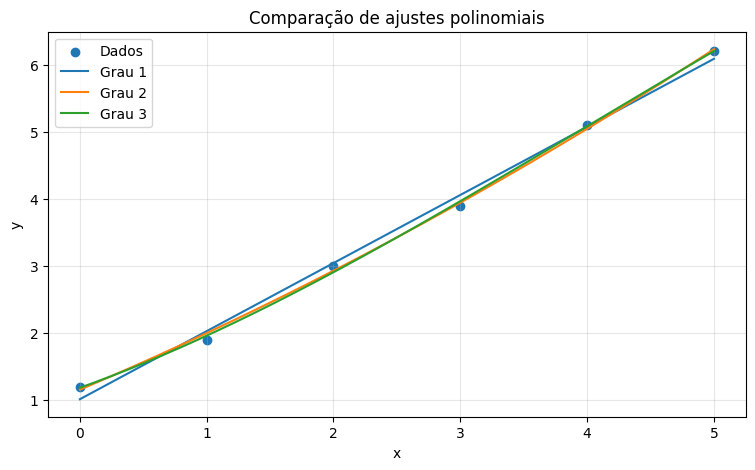

In [18]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1.2, 1.9, 3.0, 3.9, 5.1, 6.2], dtype=float)

x_plot = np.linspace(x.min(), x.max(), 400)

coef1 = np.polyfit(x, y, 1)
coef2 = np.polyfit(x, y, 2)
coef3 = np.polyfit(x, y, 3)

p1 = np.poly1d(coef1)
p2 = np.poly1d(coef2)
p3 = np.poly1d(coef3)

plt.figure(figsize=(9,5))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, p1(x_plot), label="Grau 1")
plt.plot(x_plot, p2(x_plot), label="Grau 2")
plt.plot(x_plot, p3(x_plot), label="Grau 3")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação de ajustes polinomiais")
plt.legend()
plt.show()

In [19]:
for grau, p in [(1, p1), (2, p2), (3, p3)]:
    residuos = y - p(x)
    sqr = np.sum(residuos**2)
    print(f"Grau {grau}: soma dos quadrados dos resíduos = {sqr:.8f}")

Grau 1: soma dos quadrados dos resíduos = 0.09142857
Grau 2: soma dos quadrados dos resíduos = 0.02285714
Grau 3: soma dos quadrados dos resíduos = 0.01730159


## 10. Overfitting: quando aumentar o grau deixa de ser boa ideia

Polinômios de grau alto podem ajustar extremamente bem os dados observados, mas:

- podem oscilar;
- podem ser sensíveis a pequenas perturbações;
- podem perder capacidade de generalização.

Esse é um conceito importante em modelagem, regressão e aprendizado de máquina.

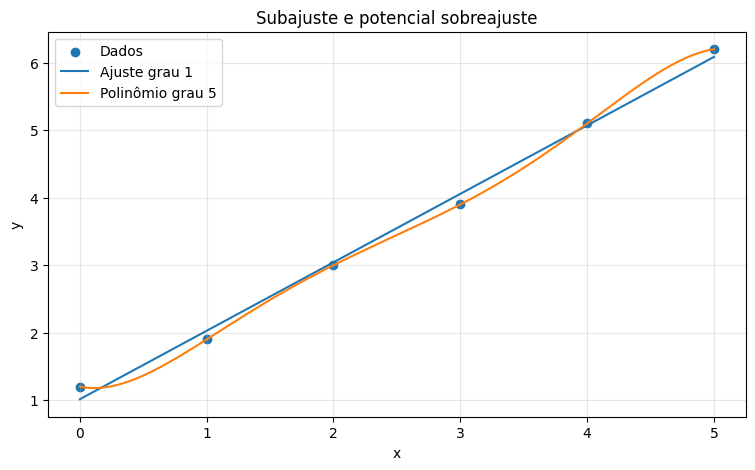

In [20]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1.2, 1.9, 3.0, 3.9, 5.1, 6.2], dtype=float)

x_plot = np.linspace(x.min(), x.max(), 500)

p1 = np.poly1d(np.polyfit(x, y, 1))
p5 = np.poly1d(np.polyfit(x, y, 5))

plt.figure(figsize=(9,5))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, p1(x_plot), label="Ajuste grau 1")
plt.plot(x_plot, p5(x_plot), label="Polinômio grau 5")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Subajuste e potencial sobreajuste")
plt.legend()
plt.show()

## 11. Exemplo mais claro de sobreajuste com ruído

Vamos gerar dados de uma tendência suave com ruído e comparar diferentes graus.

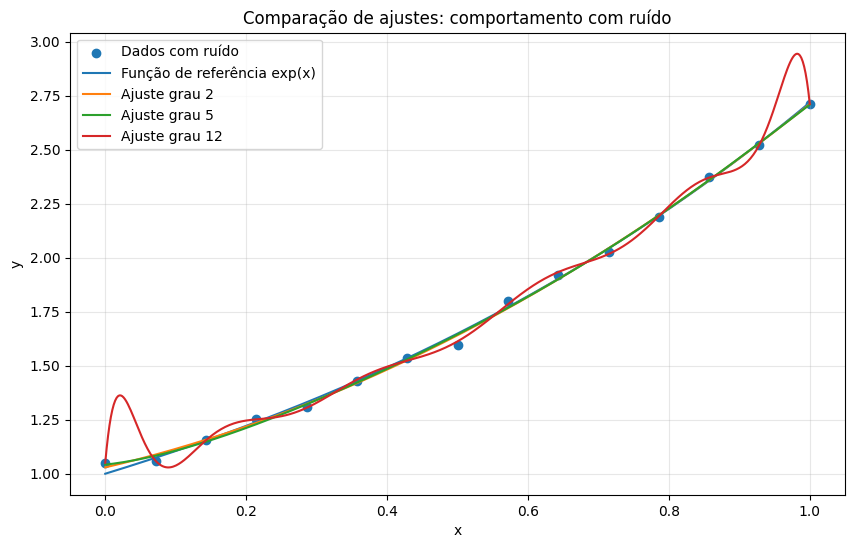

In [21]:
np.random.seed(7)

x = np.linspace(0, 1, 15)
y_true = np.exp(x)
y_noisy = y_true + 0.03*np.random.randn(len(x))

x_plot = np.linspace(0, 1, 500)

p2 = np.poly1d(np.polyfit(x, y_noisy, 2))
p5 = np.poly1d(np.polyfit(x, y_noisy, 5))
p12 = np.poly1d(np.polyfit(x, y_noisy, 12))

plt.figure(figsize=(10,6))
plt.scatter(x, y_noisy, label="Dados com ruído")
plt.plot(x_plot, np.exp(x_plot), label="Função de referência exp(x)")
plt.plot(x_plot, p2(x_plot), label="Ajuste grau 2")
plt.plot(x_plot, p5(x_plot), label="Ajuste grau 5")
plt.plot(x_plot, p12(x_plot), label="Ajuste grau 12")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação de ajustes: comportamento com ruído")
plt.legend()
plt.show()

## 12. Interpolação, spline e mínimos quadrados: três paradigmas

É importante distinguir:

### Interpolação polinomial
- passa por todos os pontos;
- pode oscilar muito.

### Splines
- passa por todos os pontos;
- usa polinômios locais;
- é mais estável.

### Mínimos quadrados
- não precisa passar pelos pontos;
- procura a melhor tendência global.

## 13. Exemplo comparativo conceitual

Aqui comparamos:
- polinômio interpolador de grau alto;
- spline cúbico;
- ajuste polinomial de grau baixo.

Esse é um excelente slide de síntese para o bloco de aproximação numérica.

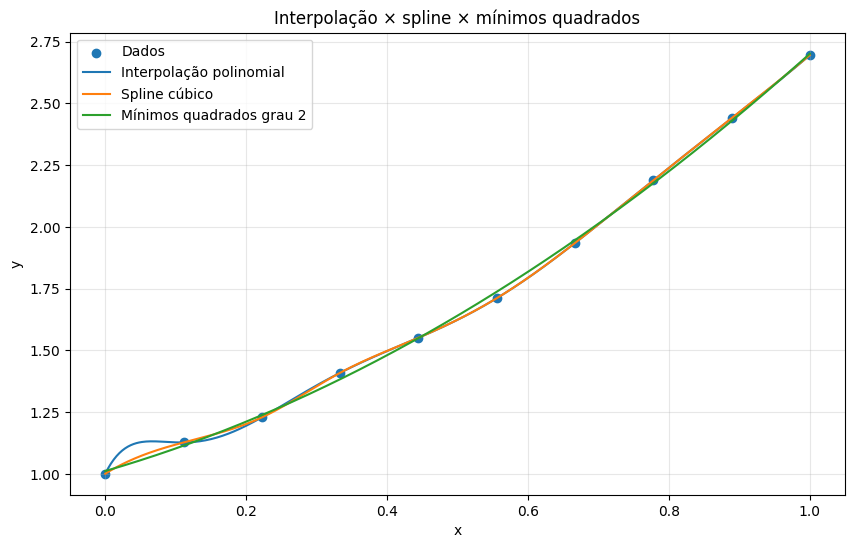

In [22]:
np.random.seed(4)
x = np.linspace(0, 1, 10)
y = np.exp(x) + 0.02*np.random.randn(len(x))

x_plot = np.linspace(0, 1, 500)

p_interp = np.poly1d(np.polyfit(x, y, len(x)-1))
p_ls = np.poly1d(np.polyfit(x, y, 2))
spline = CubicSpline(x, y)

plt.figure(figsize=(10,6))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, p_interp(x_plot), label="Interpolação polinomial")
plt.plot(x_plot, spline(x_plot), label="Spline cúbico")
plt.plot(x_plot, p_ls(x_plot), label="Mínimos quadrados grau 2")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação × spline × mínimos quadrados")
plt.legend()
plt.show()

## 14. Condicionamento do problema

Em mínimos quadrados polinomiais, a matriz \(A\) pode ficar mal condicionada, especialmente:

- para graus altos;
- quando os pontos estão mal distribuídos;
- quando usamos a base monomial \(1,x,x^2,\dots\).

Isso significa que pequenos erros nos dados podem produzir grandes variações nos coeficientes.

## 15. Exemplo: número de condição da matriz normal

Vamos observar como o condicionamento cresce com o grau do polinômio.

In [23]:
x = np.linspace(0, 1, 12)

for grau in range(1, 9):
    A = np.vander(x, N=grau+1, increasing=True)
    condA = np.linalg.cond(A)
    condATA = np.linalg.cond(A.T @ A)
    print(f"Grau {grau}: cond(A) = {condA:.3e} | cond(A^T A) = {condATA:.3e}")

Grau 1: cond(A) = 4.050e+00 | cond(A^T A) = 1.640e+01
Grau 2: cond(A) = 1.973e+01 | cond(A^T A) = 3.893e+02
Grau 3: cond(A) = 1.020e+02 | cond(A^T A) = 1.041e+04
Grau 4: cond(A) = 5.517e+02 | cond(A^T A) = 3.044e+05
Grau 5: cond(A) = 3.129e+03 | cond(A^T A) = 9.791e+06
Grau 6: cond(A) = 1.878e+04 | cond(A^T A) = 3.527e+08
Grau 7: cond(A) = 1.210e+05 | cond(A^T A) = 1.464e+10
Grau 8: cond(A) = 8.546e+05 | cond(A^T A) = 7.303e+11


## 16. Alternativas numéricas mais robustas

Para resolver problemas de mínimos quadrados com maior estabilidade, costumamos preferir:

- fatoração **QR**;
- decomposição **SVD**.

Mesmo sem aprofundar nesta aula, é importante registrar que essas abordagens evitam parte dos problemas numéricos do sistema normal.

In [24]:
x = np.linspace(0, 1, 12)
y = np.exp(x)

grau = 7
A = np.vander(x, N=grau+1, increasing=True)

c_normal = np.linalg.solve(A.T @ A, A.T @ y)
c_lstsq, *_ = np.linalg.lstsq(A, y, rcond=None)

print("Coeficientes via sistema normal:")
print(c_normal)
print("\nCoeficientes via np.linalg.lstsq:")
print(c_lstsq)
print("\nDiferença entre soluções:")
print(np.linalg.norm(c_normal - c_lstsq))

Coeficientes via sistema normal:
[1.00000000e+00 1.00000016e+00 4.99996554e-01 1.66693214e-01
 4.15661640e-02 8.53982292e-03 1.15640216e-03 3.29507415e-04]

Coeficientes via np.linalg.lstsq:
[1.00000000e+00 1.00000016e+00 4.99996553e-01 1.66693221e-01
 4.15661446e-02 8.53985233e-03 1.15638021e-03 3.29513821e-04]

Diferença entre soluções:
4.2511935281537135e-08


## 17. Resumo visual do ajuste e dos resíduos

É útil, na apresentação, mostrar os resíduos explicitamente.

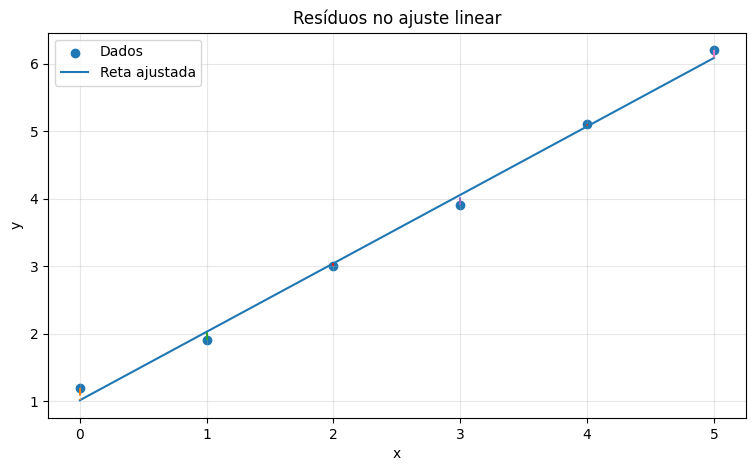

In [25]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([1.2, 1.9, 3.0, 3.9, 5.1, 6.2], dtype=float)

p = np.poly1d(np.polyfit(x, y, 1))
y_fit = p(x)

plt.figure(figsize=(9,5))
plt.scatter(x, y, label="Dados")
plt.plot(x, y_fit, label="Reta ajustada")
for xi, yi, yfi in zip(x, y, y_fit):
    plt.plot([xi, xi], [yi, yfi], linestyle="--")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Resíduos no ajuste linear")
plt.legend()
plt.show()

## 18. Síntese da aula

Nesta aula vimos que:

1. dados reais geralmente exigem **ajuste**, não interpolação;
2. mínimos quadrados minimiza a soma dos quadrados dos resíduos;
3. a solução possui uma interpretação geométrica como **projeção ortogonal**;
4. o ajuste polinomial permite maior flexibilidade, mas pode sofrer com **sobreajuste**;
5. o problema pode ser **mal condicionado**, especialmente em graus altos;
6. por isso, o método e a representação escolhidos importam muito.

## 19. Sugestões para exploração em sala

Você pode usar este notebook para:

- variar o grau do polinômio e observar o comportamento dos resíduos;
- alterar o nível de ruído dos dados;
- comparar diretamente interpolação, spline e ajuste;
- discutir o papel do condicionamento em problemas reais;
- conectar com temas futuros, como regularização e regressão.